In [67]:
import uproot

pu200 = ['job_0/events_0.delphes.root'    ]#,'job_1/events_10.delphes.root'    ,'job_2/events_20.delphes.root'    ,'job_3/events_30.delphes.root'    ,'job_4/events_40.delphes.root'    ,'job_5/events_50.delphes.root'    ,'job_6/events_60.delphes.root'    ,'job_7/events_70.delphes.root'    , 'job_8/events_80.delphes.root'    ,'job_9/events_90.delphes.root'    ,'job_10/events_100.delphes.root'    ]
pu0   = ['job_0/events_0_pu0.delphes.root']#,'job_1/events_10_pu0.delphes.root','job_2/events_20_pu0.delphes.root','job_3/events_30_pu0.delphes.root','job_4/events_40_pu0.delphes.root','job_5/events_50_pu0.delphes.root','job_6/events_60_pu0.delphes.root','job_7/events_70_pu0.delphes.root', 'job_8/events_80_pu0.delphes.root','job_9/events_90_pu0.delphes.root','job_10/events_100_pu0.delphes.root']

base_path = '/workspace/samples/ttbar/test_gen/'

value = 0
for i_0, i_200 in zip(pu0, pu200):
    pu0[value]   = base_path + i_0   + ':Delphes'
    pu200[value] = base_path + i_200 + ':Delphes' 
    value       += 1

branches = ['Tower.ET', 'Tower.Phi', 'Tower.Eta', 'GenJet.PT', 'GenJet.Phi', 'GenJet.Eta', 'Jet.PT', 'Jet.Phi', 'Jet.Eta']

d200 = uproot.concatenate(pu200, branches)
d0   = uproot.concatenate(pu0  , branches)

IndexError: cannot slice ListOffsetArray (of length 10) with 10

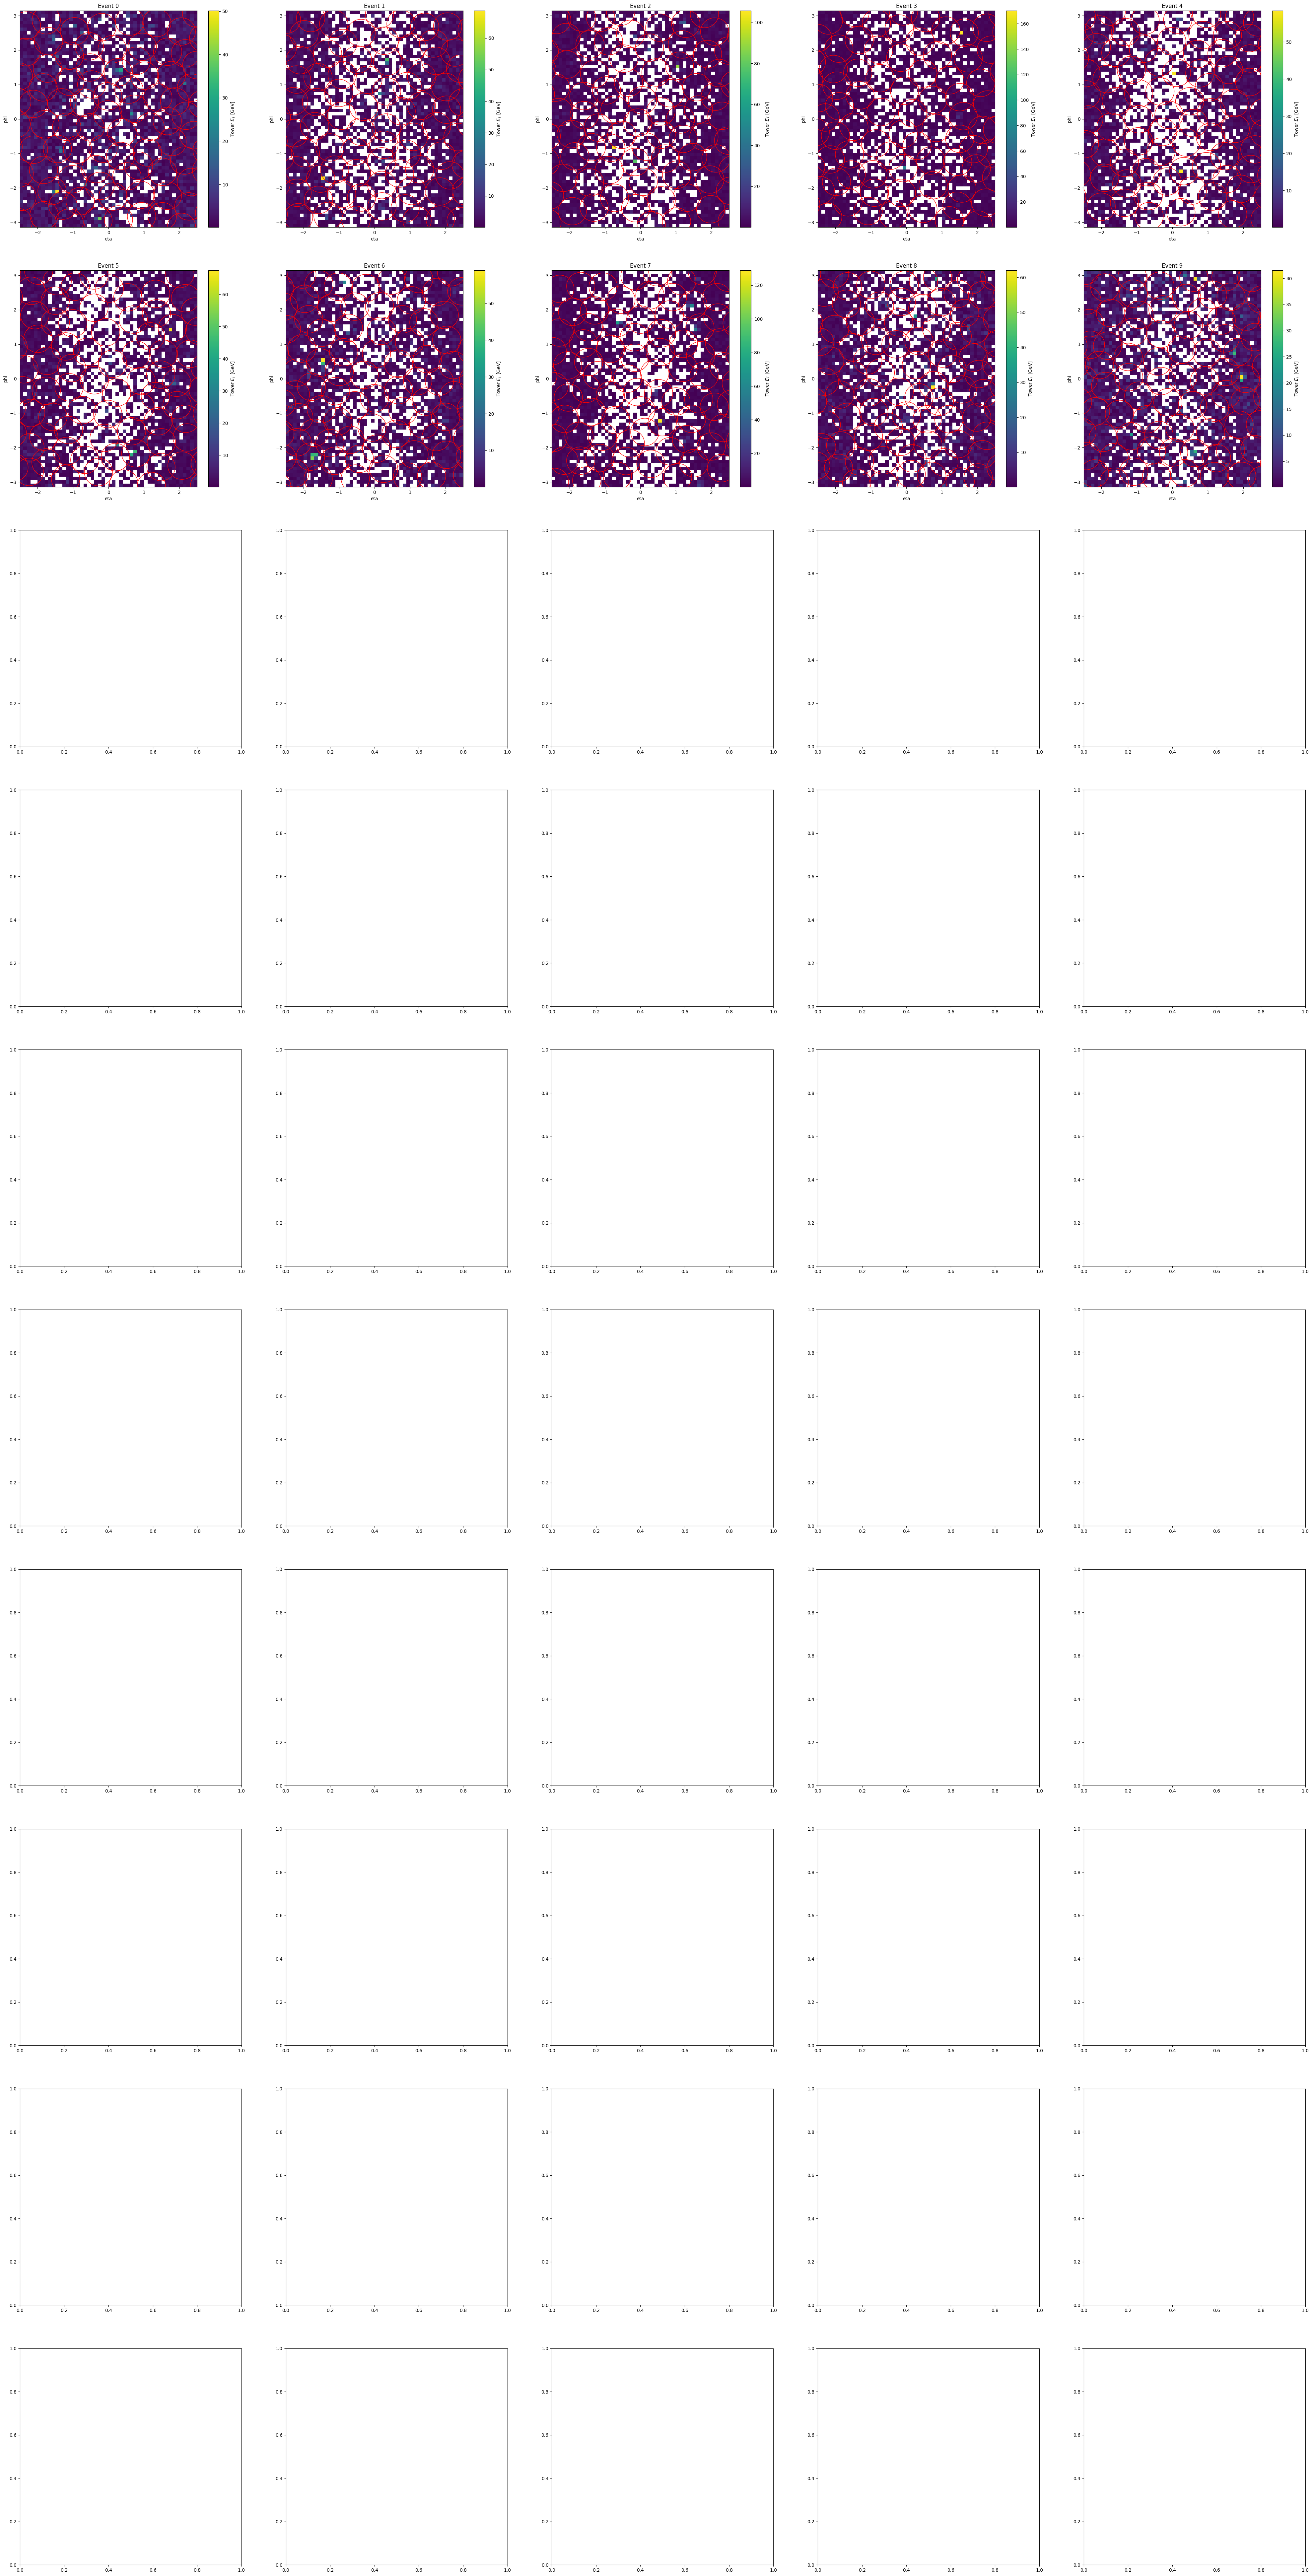

In [70]:
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import numpy              as np
import awkward            as ak

fig, ax = plt.subplots(10,5, figsize=(50,100))

phi_range = np.linspace(-np.pi, np.pi, num=64)
eta_range = np.linspace(-2.5  , 2.5  , num=50)

for x in range(10):
    for y in range(5):

        eta     = d200['Tower.Eta'][y + 5*x]
        phi     = d200['Tower.Phi'][y + 5*x]
        et      = d200['Tower.ET'][y + 5*x]
        jet_eta = d200['GenJet.Eta'][y+5*x]
        jet_phi = d200['GenJet.Phi'][y+5*x]
        jet_pt  = d200['GenJet.PT'][y+5*x] 

        mask = (eta >= eta_range[0]) & (eta <= eta_range[-1]) & (phi >= phi_range[0]) & (phi <= phi_range[-1])

        eta     = ak.to_numpy(eta[mask])
        phi     = ak.to_numpy(phi[mask])
        et      = ak.to_numpy(et[mask])

        h = ax[x, y].hist2d(
            eta,
            phi,
            weights = et,
            bins    = (len(eta_range),len(phi_range)),
            range   = [[eta_range[0], eta_range[-1]], [phi_range[0], phi_range[-1]]],
            cmap    = 'viridis',
            cmin    = 0.0001
        )

        cbar = plt.colorbar(h[3], ax=ax[x, y])
        cbar.set_label('Tower $E_T$ [GeV]')

        ax[x, y].set_xlabel('eta')
        ax[x, y].set_ylabel('phi')
        ax[x, y].set_title(f'Event {y + 5*x}')

        ax[x, y].set_xlim(eta_range[0],eta_range[-1])
        ax[x, y].set_ylim(phi_range[0],phi_range[-1])

        for j_eta, j_phi in zip(ak.to_numpy(jet_eta), ak.to_numpy(jet_phi)):
            circle = mpatches.Circle((j_eta, j_phi), 0.4, color='red', fill=False)
            ax[x,y].add_patch(circle)
            ax[x,y].set_label('GenJet') 

plt.show()